In [1]:

import pandas as pd  # data cleaning/pre-processing
import numpy as np  # np.array
import matplotlib.pyplot as plt  # data viz
import datetime  # working with dates (feature extraction)
from sklearn.linear_model import LinearRegression  # linear regression model

df= pd.read_csv('Lumber Futures Historical Data.csv')
df

,Date,Price,Open,High,Low,Vol.,Change %
0,01/06/2023,354.00,359.50,359.50,349.00,0.13K,-0.03%
1,01/05/2023,354.10,359.50,361.80,352.10,0.17K,-1.78%
2,01/04/2023,360.50,366.00,370.00,360.50,0.14K,-0.83%
3,01/03/2023,363.50,370.20,370.20,362.00,0.12K,-1.94%
4,01/01/2023,370.70,370.70,370.70,370.70,NaN,-0.80%
...,...,...,...,...,...,...,...
767,01/10/2020,392.00,390.60,393.90,390.40,0.05K,0.23%
768,01/09/2020,391.10,400.10,401.60,387.30,0.09K,-1.73%
769,01/08/2020,398.00,395.40,402.90,394.00,0.13K,0.66%
770,01/07/2020,395.40,393.20,400.00,393.00,0.11K,-0.40%


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df


,Date,Price,Open,High,Low,Vol.,Change %
0,2023-01-06,354.00,359.50,359.50,349.00,0.13K,-0.03%
1,2023-01-05,354.10,359.50,361.80,352.10,0.17K,-1.78%
2,2023-01-04,360.50,366.00,370.00,360.50,0.14K,-0.83%
3,2023-01-03,363.50,370.20,370.20,362.00,0.12K,-1.94%
4,2023-01-01,370.70,370.70,370.70,370.70,NaN,-0.80%
...,...,...,...,...,...,...,...
767,2020-01-10,392.00,390.60,393.90,390.40,0.05K,0.23%
768,2020-01-09,391.10,400.10,401.60,387.30,0.09K,-1.73%
769,2020-01-08,398.00,395.40,402.90,394.00,0.13K,0.66%
770,2020-01-07,395.40,393.20,400.00,393.00,0.11K,-0.40%


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      772 non-null    datetime64[ns]
 1   Price     772 non-null    object        
 2   Open      772 non-null    object        
 3   High      772 non-null    object        
 4   Low       772 non-null    object        
 5   Vol.      757 non-null    object        
 6   Change %  772 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 42.3+ KB


In [4]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      772 non-null    datetime64[ns]
 1   Price     772 non-null    float64       
 2   Open      772 non-null    object        
 3   High      772 non-null    object        
 4   Low       772 non-null    object        
 5   Vol.      757 non-null    object        
 6   Change %  772 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 42.3+ KB


In [6]:
#feature extraction
df["Timestamp"] = df["Date"].apply(datetime.datetime.timestamp)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       772 non-null    datetime64[ns]
 1   Price      772 non-null    float64       
 2   Open       772 non-null    object        
 3   High       772 non-null    object        
 4   Low        772 non-null    object        
 5   Vol.       757 non-null    object        
 6   Change %   772 non-null    object        
 7   Timestamp  772 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 48.4+ KB


In [8]:
X = df[["Timestamp"]]

Y=df["Price"]

In [9]:
split_ratio = .8
split_index = int(len(df) * split_ratio)
X_train,X_test = X[:split_index],X[split_index:]
Y_train,Y_test = Y[:split_index],Y[split_index:]


In [10]:
model = LinearRegression()
model.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
prediction_date = "2023-11-01"
prediction_timestamp= datetime.datetime.strptime(prediction_date, "%Y-%m-%d").timestamp()

In [12]:
prediction_timestamp

1698784200.0

In [13]:
prediction_input = np.array([[prediction_timestamp]])

In [14]:
prediction = model.predict(prediction_input)

/home/nosrati/anaconda3/envs/ml_learning/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
df_with_prediction = df.copy()
new_row = pd.DataFrame([{"Timestamp": prediction_timestamp, "Price": prediction[0]}])

# Concatenate it with the original DataFrame
df_with_prediction = pd.concat([df_with_prediction, new_row], ignore_index=True)

In [16]:

def safe_fromtimestamp(x):
    try:
        return datetime.datetime.fromtimestamp(float(x))
    except Exception as e:
        return None  # or handle differently if needed

df_with_prediction['Date'] = df_with_prediction["Timestamp"].apply(safe_fromtimestamp)


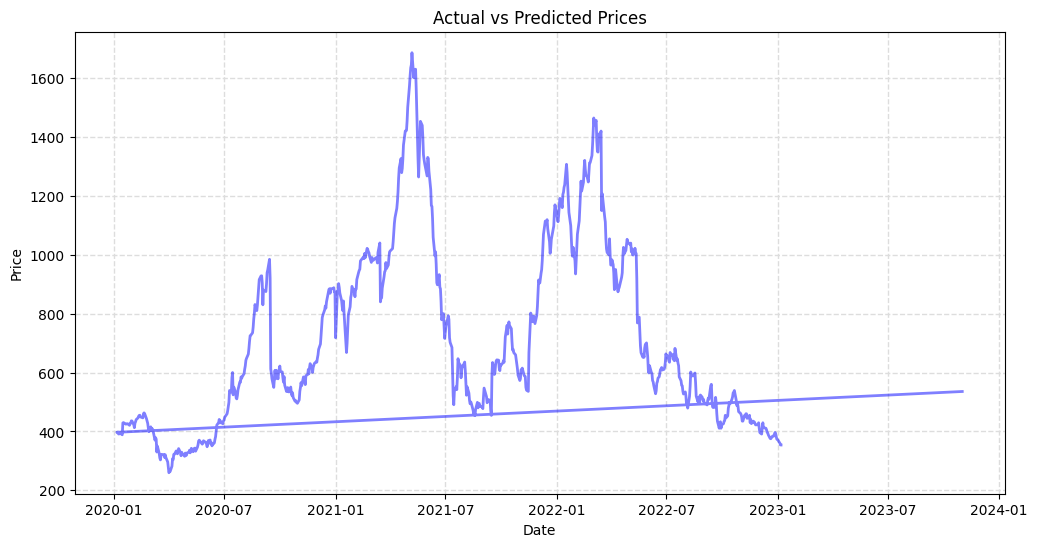

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df_with_prediction['Date'], df_with_prediction['Price'], label='Actual Prices' , color='blue', linewidth=2 , alpha=0.5)
plt.grid( color = '#dddddd', linestyle = '--', linewidth = 1)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

